# Used Car Price Prediction

## Loading the Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

sns.set_theme(style='whitegrid', palette='muted') # themes
plt.rcParams['figure.dpi'] = 110

import warnings
warnings.filterwarnings('ignore') # ignore warnings

In [2]:
df = pd.read_csv("Car details v3.csv")

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
print(f"Shape: {df.shape}")

Shape: (8128, 13)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [6]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,8128.0,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
seats,7907.0,5.416719,0.959588,2.0,5.0,5.0,5.0,14.0


In [7]:
# Summary statistics for object/categorical columns
df.describe(include=['O']).T

,count,unique,top,freq
name,8128,2058,Maruti Swift Dzire VDI,129
fuel,8128,4,Diesel,4402
seller_type,8128,3,Individual,6766
transmission,8128,2,Manual,7078
owner,8128,5,First Owner,5289
mileage,7907,393,18.9 kmpl,225
engine,7907,121,1248 CC,1017
max_power,7913,322,74 bhp,377
torque,7906,441,190Nm@ 2000rpm,530


In [8]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [9]:
# Check unique value counts — helps identify high-cardinality columns
# Columns with very high nunique (like 'name') are likely IDs or free text
df.nunique().sort_values(ascending=False)

name             2058
km_driven         921
selling_price     677
torque            441
mileage           393
max_power         322
engine            121
year               29
seats               9
owner               5
fuel                4
seller_type         3
transmission        2
dtype: int64

## Simple EDA

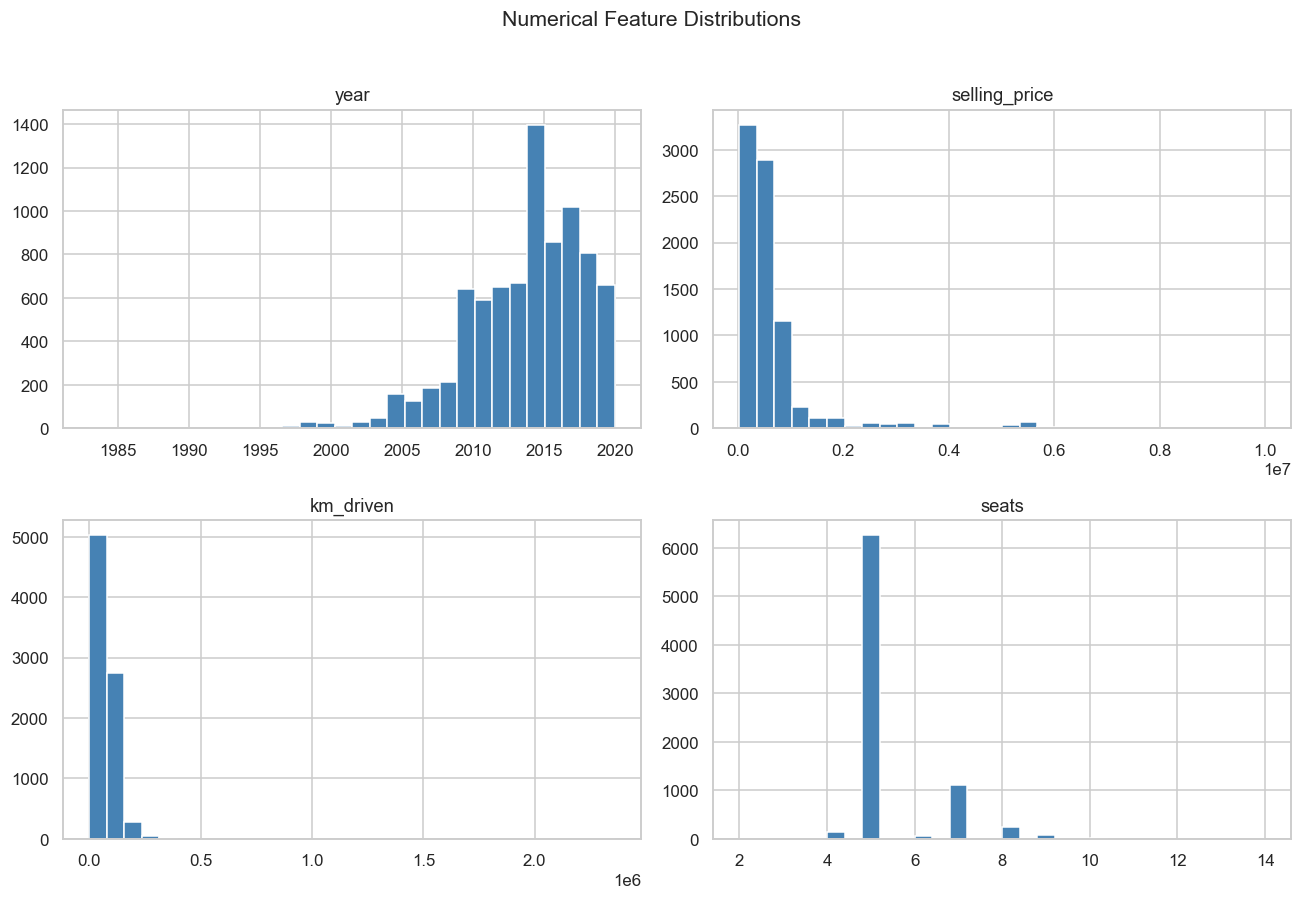

In [10]:
df.hist(figsize=(12, 8), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

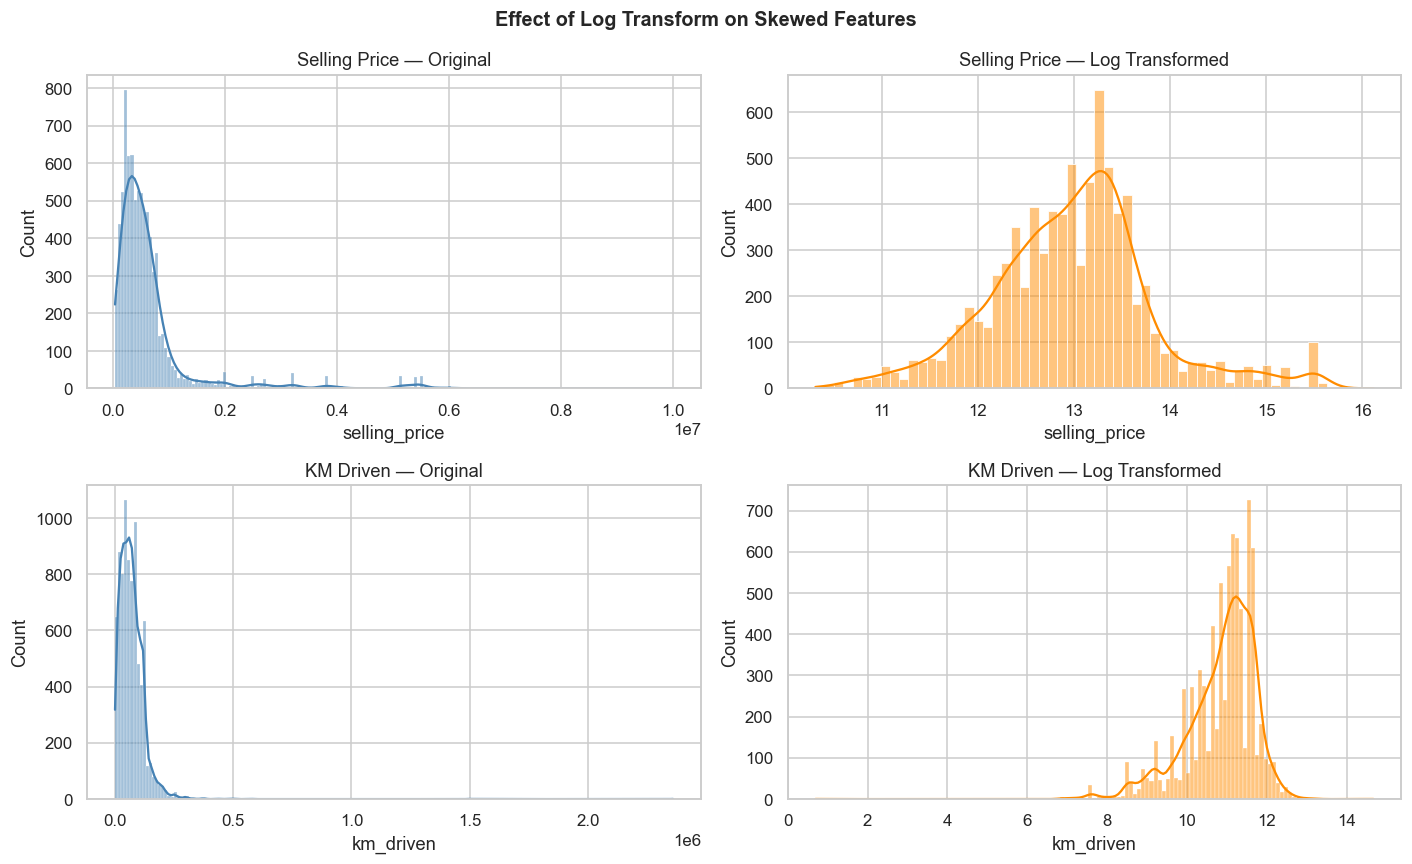

In [11]:
# Visualise the effect of log transform on both features
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.histplot(df['selling_price'],     kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title(f"Selling Price — Original")

sns.histplot(np.log1p(df['selling_price']), kde=True, ax=axes[0,1], color='darkorange')
axes[0,1].set_title(f"Selling Price — Log Transformed")

sns.histplot(df['km_driven'],         kde=True, ax=axes[1,0], color='steelblue')
axes[1,0].set_title(f"KM Driven — Original")

sns.histplot(np.log1p(df['km_driven']),     kde=True, ax=axes[1,1], color='darkorange')
axes[1,1].set_title(f"KM Driven — Log Transformed")

plt.suptitle('Effect of Log Transform on Skewed Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

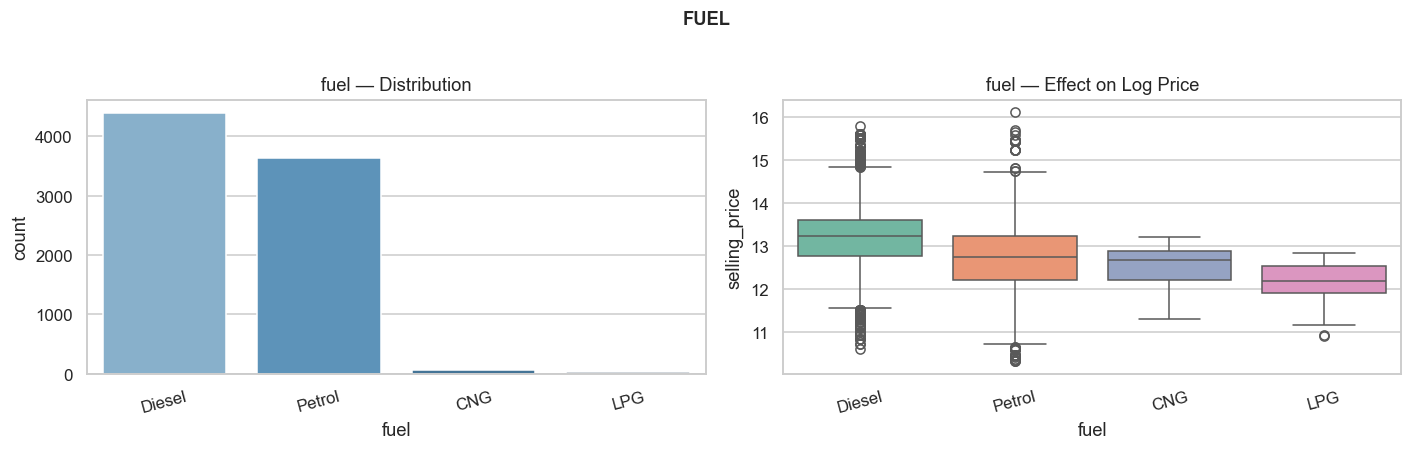

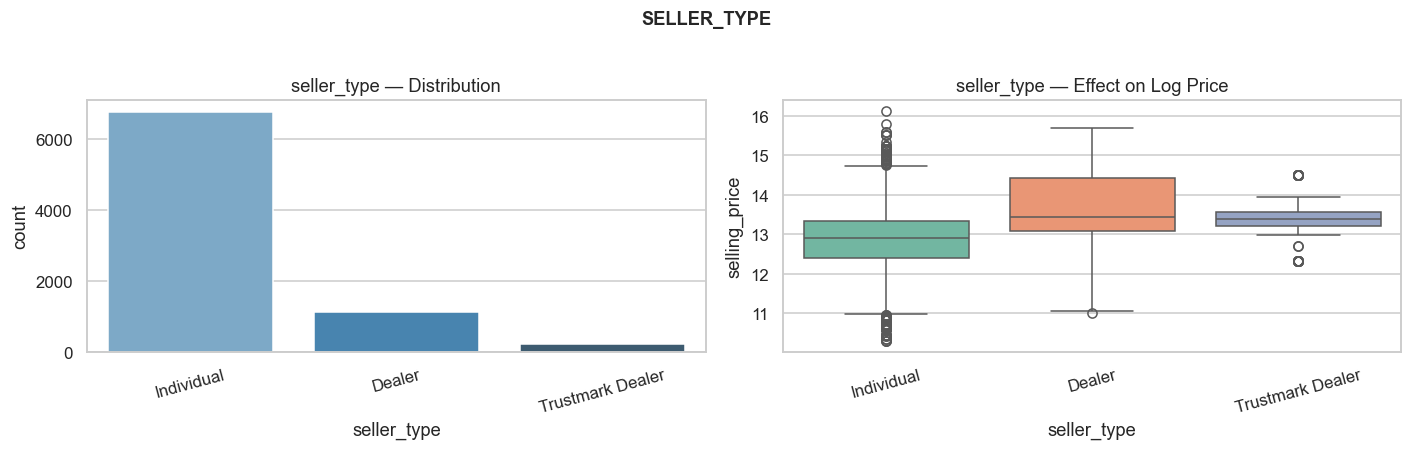

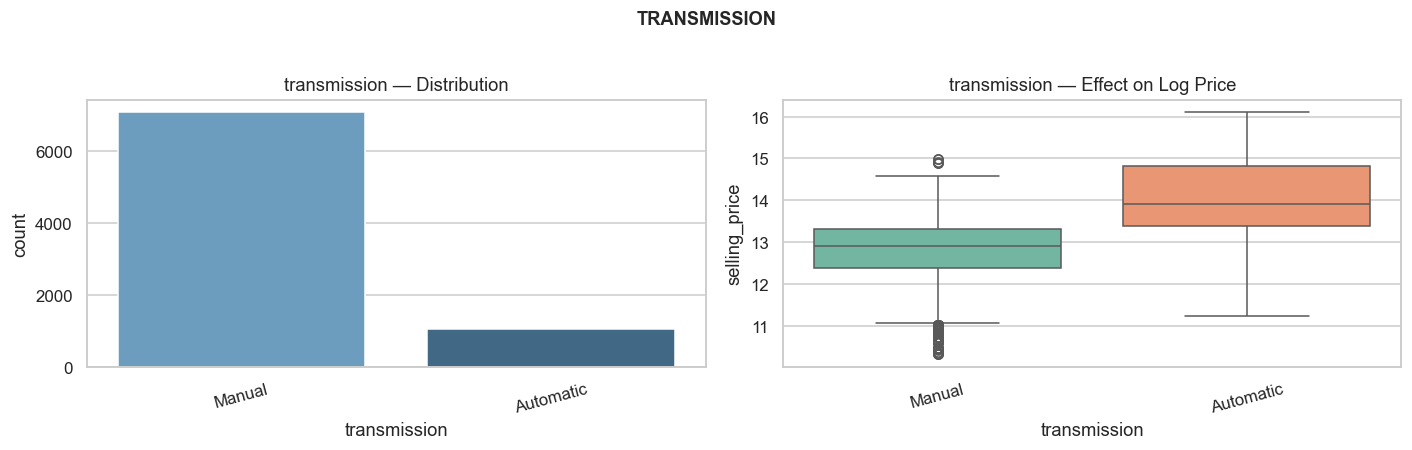

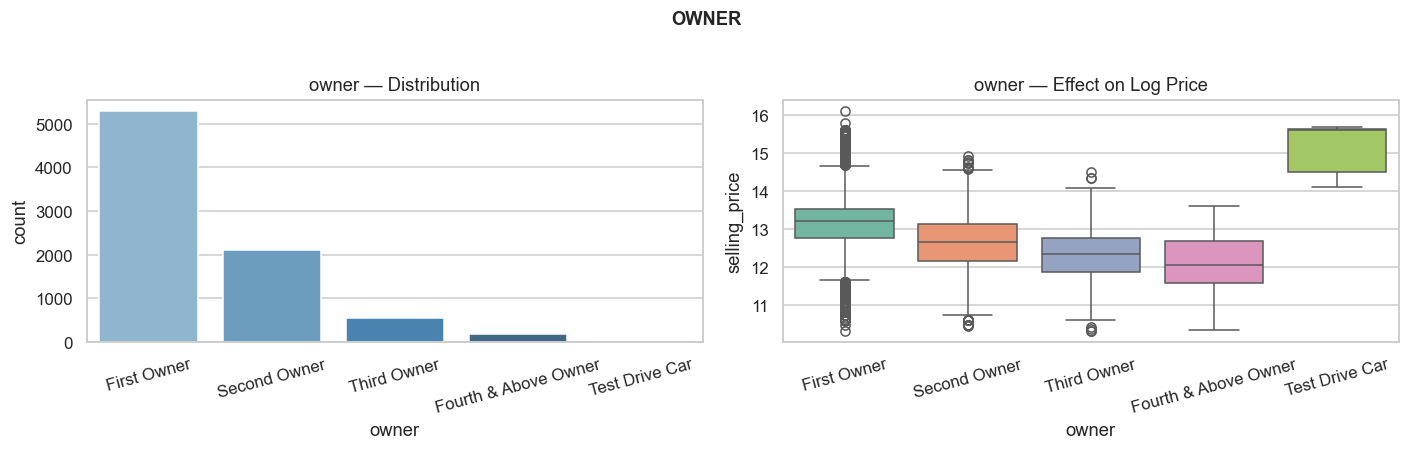

In [12]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='Blues_d', ax=axes[0])
    axes[0].set_title(f'{col} — Distribution')
    axes[0].tick_params(axis='x', rotation=15)

    sns.boxplot(data=df, x=col, y=np.log1p(df['selling_price']),
                order=order, palette='Set2', ax=axes[1])
    axes[1].set_title(f'{col} — Effect on Log Price')
    axes[1].tick_params(axis='x', rotation=15)

    plt.suptitle(col.upper(), fontweight='bold', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

## Data Preprocessing

In [13]:
# This dataset has a small number of missing values (<5%) — safe to drop rows
df = df.dropna()
print(f"Shape after dropping nulls: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")

Shape after dropping nulls: (7906, 13)
Remaining nulls: 0


#### Train / Test Split

In [14]:
X = df
y = df['selling_price']

# 80% training, 20% testing — random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# Apply Log1p transform to skewed features
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

X_train['log_selling_price'] = np.log1p(X_train['selling_price'])
X_test['log_selling_price'] = np.log1p(X_test['selling_price'])

X_train['log_km_driven'] = np.log1p(X_train['km_driven'])
X_test['log_km_driven'] = np.log1p(X_test['km_driven'])

# Convert year to car_age — more meaningful for modeling
X_train['car_age'] = 2026 - X_train['year']
X_test['car_age'] = 2026 - X_test['year']

In [16]:
# Drop original columns replaced by engineered versions
X_train.drop(columns=['selling_price', 'km_driven', 'year'], inplace=True)
X_test.drop(columns=['selling_price', 'km_driven', 'year'], inplace=True)

print("Remaining columns:")
print(X_train.dtypes)

Remaining columns:
name                     str
fuel                     str
seller_type              str
transmission             str
owner                    str
mileage                  str
engine                   str
max_power                str
torque                   str
seats                float64
log_selling_price    float64
log_km_driven        float64
car_age                int64
dtype: object


In [17]:
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    print(f"{col}: {X_train[col].unique()}")

fuel: <StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG']
Length: 4, dtype: str
seller_type: <StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str
transmission: <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
owner: <StringArray>
[         'First Owner',          'Third Owner',         'Second Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str


In [18]:
# Grouping rare categories of seats
print("Seats distribution on training data before grouping:")
print(X_train['seats'].value_counts())
print()

def categorize_seats(val):
    if val == 5:   return '5'
    elif val == 7: return '7'
    else:          return 'Rare'

X_train['seats'] = X_train['seats'].apply(categorize_seats)
X_test['seats'] = X_test['seats'].apply(categorize_seats)

print("Seats distribution on training data after grouping:")
print(X_train['seats'].value_counts())

Seats distribution on training data before grouping:
seats
5.0     4983
7.0      915
8.0      192
4.0      106
9.0       63
6.0       46
10.0      17
2.0        2
Name: count, dtype: int64

Seats distribution on training data after grouping:
seats
5       4983
7        915
Rare     426
Name: count, dtype: int64


In [19]:
# Extract numeric values from string columns with units
# e.g. "1248 CC" → 1248.0,  "82.85bhp" → 82.85,  "19.67 kmpl" → 19.67
X_train['mileage']   = X_train['mileage'].str.extract(r'([\d.]+)').astype(float)
X_train['engine']    = X_train['engine'].str.extract(r'([\d.]+)').astype(float)
X_train['max_power'] = X_train['max_power'].str.extract(r'([\d.]+)').astype(float)

X_test['mileage']   = X_test['mileage'].str.extract(r'([\d.]+)').astype(float)
X_test['engine']    = X_test['engine'].str.extract(r'([\d.]+)').astype(float)
X_test['max_power'] = X_test['max_power'].str.extract(r'([\d.]+)').astype(float)

# Drop columns we cannot use
X_train.drop(columns=['name', 'torque'], inplace=True)
X_test.drop(columns=['name', 'torque'], inplace=True)

In [20]:
X_train.head()

,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,log_selling_price,log_km_driven,car_age
3064,Petrol,Individual,Manual,First Owner,18.90,998.0,67.1,5,11.813037,11.049317,20
2522,Diesel,Individual,Manual,First Owner,20.46,1461.0,83.8,5,13.102163,11.461643,13
1819,Petrol,Individual,Manual,First Owner,23.01,999.0,67.0,5,12.691584,10.545368,9
6600,Diesel,Individual,Manual,Third Owner,15.40,2179.0,120.0,7,13.710151,11.156265,11
7909,Diesel,Individual,Manual,First Owner,21.50,1497.0,108.5,5,13.652993,9.159152,8


In [21]:
# Force Skikit-Learn to return Panda Dataframe
sklearn.set_config(transform_output="pandas")

oh_encoder = OneHotEncoder(drop="first", sparse_output=False, dtype=int)

transmission_order = ['Manual', 'Automatic']
owner_order = ['Fourth & Above Owner', 'Third Owner', 'Second Owner', 'First Owner', 'Test Drive Car']

ord_encoder = OrdinalEncoder(categories=[transmission_order, owner_order])

cols_to_scale = ['mileage', 'engine', 'max_power', 'log_km_driven', 'car_age']

scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        # One-hot encoding — for nominal features (no natural order) 
        ("onehot", oh_encoder, ["fuel", "seller_type", "seats"]),
        # Ordinal encoding — only for features with a natural order
        # transmission: Manual < Automatic (automatic cars are priced higher)
        # owner: Test Drive Car (4) > First Owner (3) > Second (2) > Third (1) > Fourth+ (0)
        ("ordinal", ord_encoder, ["transmission", "owner"]),
        ("scale", scaler, cols_to_scale),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [22]:
X_train.head()

,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,seats_7,seats_Rare,transmission,owner,mileage,engine,max_power,log_km_driven,car_age,log_selling_price
3064,0,0,1,1,0,0,0,0.0,3.0,-0.123214,-0.917523,-0.687326,0.225121,2.054894,11.813037
2522,1,0,0,1,0,0,0,0.0,3.0,0.259743,-0.003221,-0.221194,0.695447,0.253336,13.102163
1819,0,0,1,1,0,0,0,0.0,3.0,0.885731,-0.915549,-0.690117,-0.349717,-0.776125,12.691584
6600,1,0,0,1,0,1,0,0.0,1.0,-0.982414,1.414639,0.789225,0.347112,-0.261394,13.710151
7909,1,0,0,1,0,0,0,0.0,3.0,0.515048,0.067870,0.468235,-1.930926,-1.033490,13.652993


In [23]:
X_train.dtypes

fuel_Diesel                       int64
fuel_LPG                          int64
fuel_Petrol                       int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
seats_7                           int64
seats_Rare                        int64
transmission                    float64
owner                           float64
mileage                         float64
engine                          float64
max_power                       float64
log_km_driven                   float64
car_age                         float64
log_selling_price               float64
dtype: object

#### Correlation

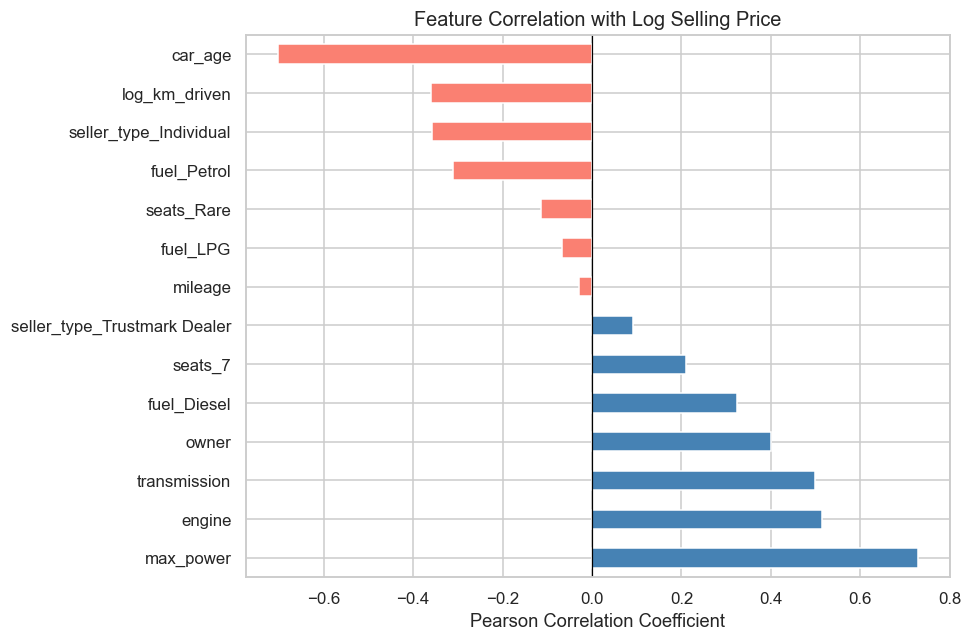

max_power                       0.7286
engine                          0.5153
transmission                    0.4979
owner                           0.3999
fuel_Diesel                     0.3241
seats_7                         0.2112
seller_type_Trustmark Dealer    0.0921
mileage                        -0.0294
fuel_LPG                       -0.0676
seats_Rare                     -0.1131
fuel_Petrol                    -0.3106
seller_type_Individual         -0.3588
log_km_driven                  -0.3607
car_age                        -0.7026


In [24]:
corr = X_train.corr()
target_corr = (corr['log_selling_price']
               .drop('log_selling_price')
               .sort_values(ascending=False))

# Visualise as a horizontal bar chart — easier to read than raw numbers
plt.figure(figsize=(9, 6))
colors = ['steelblue' if v > 0 else 'salmon' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Log Selling Price', fontsize=13)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print(target_corr.round(4).to_string())

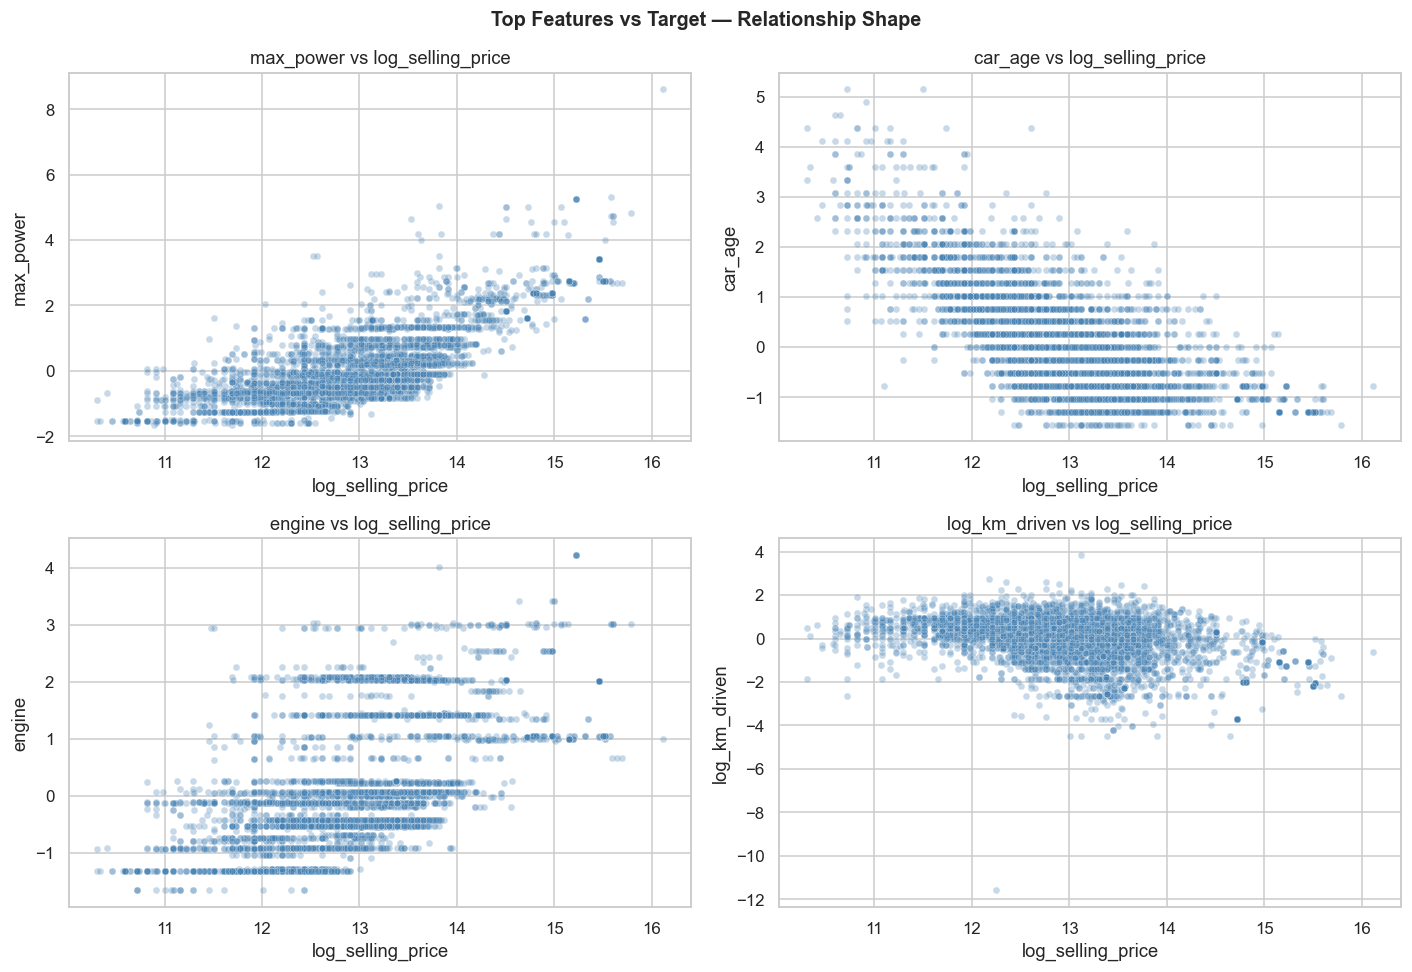

In [25]:
top_features = ['max_power', 'car_age', 'engine', 'log_km_driven']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes.flatten(), top_features):
    sns.scatterplot(data=X_train, x='log_selling_price', y=col,
                    alpha=0.3, s=20, ax=ax, color='steelblue')
    ax.set_title(f'{col} vs log_selling_price')
    ax.set_xlabel('log_selling_price')
    ax.set_ylabel(col)

plt.suptitle('Top Features vs Target — Relationship Shape', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Remove the target variable before model training
X_train.drop(columns="log_selling_price", inplace=True)
X_test.drop(columns="log_selling_price", inplace=True)
X_train.head()

,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,seats_7,seats_Rare,transmission,owner,mileage,engine,max_power,log_km_driven,car_age
3064,0,0,1,1,0,0,0,0.0,3.0,-0.123214,-0.917523,-0.687326,0.225121,2.054894
2522,1,0,0,1,0,0,0,0.0,3.0,0.259743,-0.003221,-0.221194,0.695447,0.253336
1819,0,0,1,1,0,0,0,0.0,3.0,0.885731,-0.915549,-0.690117,-0.349717,-0.776125
6600,1,0,0,1,0,1,0,0.0,1.0,-0.982414,1.414639,0.789225,0.347112,-0.261394
7909,1,0,0,1,0,0,0,0.0,3.0,0.515048,0.067870,0.468235,-1.930926,-1.033490


## Model Selection, Implementation & Training

### Linear Regression

In [27]:
# Training Linear Regression model
lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)
lin_preds = lin_reg.predict(X_train)

In [28]:
lin_preds[:5].round(2)

array([11.65, 12.86, 12.89, 13.49, 13.78])

In [29]:
actual_lin_preds = np.expm1(lin_preds) # Predictions in actual price (INR)
actual_lin_preds[:5].round(2)

array([115149.56, 385314.06, 398159.65, 718983.8 , 967186.6 ])

In [30]:
actual_values = np.expm1(y_train)
actual_values[:5].values

array([135000., 490000., 325000., 900000., 850000.])

In [31]:
# MAE and RMSE of the predictions made by the Linear Regression model
lin_mae = mean_absolute_error(actual_values, actual_lin_preds)
lin_rmse = np.sqrt(mean_squared_error(actual_values, actual_lin_preds))
print(f"Linear Regression MAE: {lin_mae:.2f}")
print(f"Linear Regression RMSE: {lin_rmse:.2f}")

Linear Regression MAE: 147805.98
Linear Regression RMSE: 338244.36


In [32]:
# Helpers to calculate MAE and RMSE in actual price (INR)
def mae_in_money(true, pred):
    actual_true = np.expm1(true)
    actual_pred = np.expm1(pred)
    return mean_absolute_error(actual_true, actual_pred)
    
def rmse_in_money(true, pred):
    actual_true = np.expm1(true)
    actual_pred = np.expm1(pred)
    return np.sqrt(mean_squared_error(actual_true, actual_pred))

# scorers
money_mae_scorer = make_scorer(mae_in_money, response_method="predict", greater_is_better=False)
money_rmse_scorer = make_scorer(rmse_in_money, response_method="predict", greater_is_better=False)

In [33]:
# Evaluate the Linear Regression model's performance using cross-validation.
lin_maes = -cross_val_score(lin_reg, X_train, y_train, scoring=money_mae_scorer, cv=5)
pd.Series(lin_maes).describe()

count         5.000000
mean     148622.481967
std        7364.635885
min      136904.504676
25%      146988.507393
50%      149739.892406
75%      154076.437453
max      155403.067904
dtype: float64

In [34]:
lin_rmses = -cross_val_score(lin_reg, X_train, y_train, scoring=money_rmse_scorer, cv=5)
pd.Series(lin_rmses).describe()

count         5.000000
mean     345763.964256
std       67354.790522
min      284081.783274
25%      323955.212438
50%      329134.525611
75%      330334.549661
max      461313.750296
dtype: float64

### Decision Tree Regression

In [35]:
# Training Decision Tree Regression model
tree_reg = DecisionTreeRegressor(random_state=42)

tree_reg.fit(X_train, y_train)
tree_preds = tree_reg.predict(X_train)

In [36]:
tree_preds[:5].round(2)

array([11.81, 13.1 , 12.69, 13.71, 13.65])

In [37]:
actual_tree_preds = np.expm1(tree_preds) # Predictions in actual price (INR)
actual_tree_preds[:5].round(2)

array([135000., 490000., 325000., 900000., 850000.])

In [38]:
actual_values[:5].values

array([135000., 490000., 325000., 900000., 850000.])

In [39]:
# MAE and RMSE of the predictions made by the Decision Tree Regression model
tree_mae = mean_absolute_error(actual_values, actual_tree_preds)
tree_rmse = np.sqrt(mean_squared_error(actual_values, actual_tree_preds))
print(f"Decision Tree Regression MAE: {tree_mae:.2f}")
print(f"Decision Tree Regression RMSE: {tree_rmse:.2f}")

Decision Tree Regression MAE: 3688.06
Decision Tree Regression RMSE: 15479.03


In [40]:
# Evaluate the Decision Tree Regression model's performance using cross-validation.
tree_maes = -cross_val_score(tree_reg, X_train, y_train, scoring=money_mae_scorer, cv=5)
pd.Series(tree_maes).describe()

count        5.000000
mean     84671.865598
std       5182.945600
min      79457.672911
25%      80300.568093
50%      84986.020866
75%      86301.028950
max      92314.037171
dtype: float64

In [41]:
tree_rmses = -cross_val_score(tree_reg, X_train, y_train, scoring=money_rmse_scorer, cv=5)
pd.Series(tree_rmses).describe()

count         5.000000
mean     183276.578202
std       35678.873854
min      143841.885844
25%      156320.856183
50%      189609.012477
75%      191321.005076
max      235290.131431
dtype: float64

### Random Forest Regression

In [42]:
# Training Random Forest Regression model
forest_reg = RandomForestRegressor(random_state=42)

forest_reg.fit(X_train, y_train)
forest_preds = forest_reg.predict(X_train)

In [43]:
forest_preds[:5].round(2)

array([11.87, 13.06, 12.69, 13.74, 13.7 ])

In [44]:
actual_forest_preds = np.expm1(forest_preds) # Predictions in actual price (INR)
actual_forest_preds[:5].round(2)

array([143288.39, 470534.86, 323360.72, 930380.51, 892782.04])

In [45]:
actual_values[:5].values

array([135000., 490000., 325000., 900000., 850000.])

In [46]:
# MAE and RMSE of the predictions made by the Random Forest Regression model
forest_mae = mean_absolute_error(actual_values, actual_forest_preds)
forest_rmse = np.sqrt(mean_squared_error(actual_values, actual_forest_preds))
print(f"Random Forest Regression MAE: {forest_mae:.2f}")
print(f"Random Forest Regression RMSE: {forest_rmse:.2f}") 

Random Forest Regression MAE: 27713.09
Random Forest Regression RMSE: 64203.84


In [47]:
# Evaluate the Random Forest Regression model's performance using cross-validation.
forest_maes = -cross_val_score(forest_reg, X_train, y_train, scoring=money_mae_scorer, cv=5)
pd.Series(forest_maes).describe()

count        5.000000
mean     72476.249668
std       4497.679655
min      65871.737548
25%      70357.763715
50%      73328.795221
75%      75666.465621
max      77156.486233
dtype: float64

In [48]:
forest_rmses = -cross_val_score(forest_reg, X_train, y_train, scoring=money_rmse_scorer, cv=5)
pd.Series(forest_rmses).describe()

count         5.000000
mean     157048.241622
std       34742.886767
min      120259.131524
25%      131628.620592
50%      149650.248069
75%      178596.442712
max      205106.765213
dtype: float64

### Hyperparameter Tuning for Random Forest Regression model

In [49]:
# Hyperparameter tuning for the Random Forest Regression model (best model so far)
param_distributions = {
    "n_estimators": randint(100, 501),
    "max_features": randint(3, 14),
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

random_search = RandomizedSearchCV(
    forest_reg, 
    param_distributions,
    n_iter=50, 
    cv=5, 
    scoring=money_rmse_scorer, # help scorer
    return_train_score=True,
    random_state=42,
    n_jobs=2
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': <scipy.stats....t 0x168aaa8d0>, 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(r...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valid

In [50]:
print(f"Best parameters: {random_search.best_params_}")
print(f"Best RMSE score: {-random_search.best_score_}")

Best parameters: {'max_depth': 20, 'max_features': 13, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 259}
Best RMSE score: 155420.61369681792


##  Evaluation 

In [52]:
# Retrieve the best model to make predictions on the test set
final_model = random_search.best_estimator_ 
final_preds = final_model.predict(X_test)

In [53]:
actual_final_preds = np.expm1(final_preds)
actual_values_test = np.expm1(y_test)

print("Predicted values:", actual_final_preds[:5].round(2))
print("Actual values:", actual_values_test[:5].values)

Predicted values: [556730.29 515519.09 154556.47 330270.77 602325.62]
Actual values: [501000. 440000. 140000. 476999. 620000.]


In [54]:
final_mae = mean_absolute_error(actual_values_test, actual_final_preds)
final_rmse = np.sqrt(mean_squared_error(actual_values_test, actual_final_preds))
print(f"Final MAE: {final_mae:.2f}")
print(f"Final RMSE: {final_rmse:.2f}")

Final MAE: 60563.51
Final RMSE: 108608.08


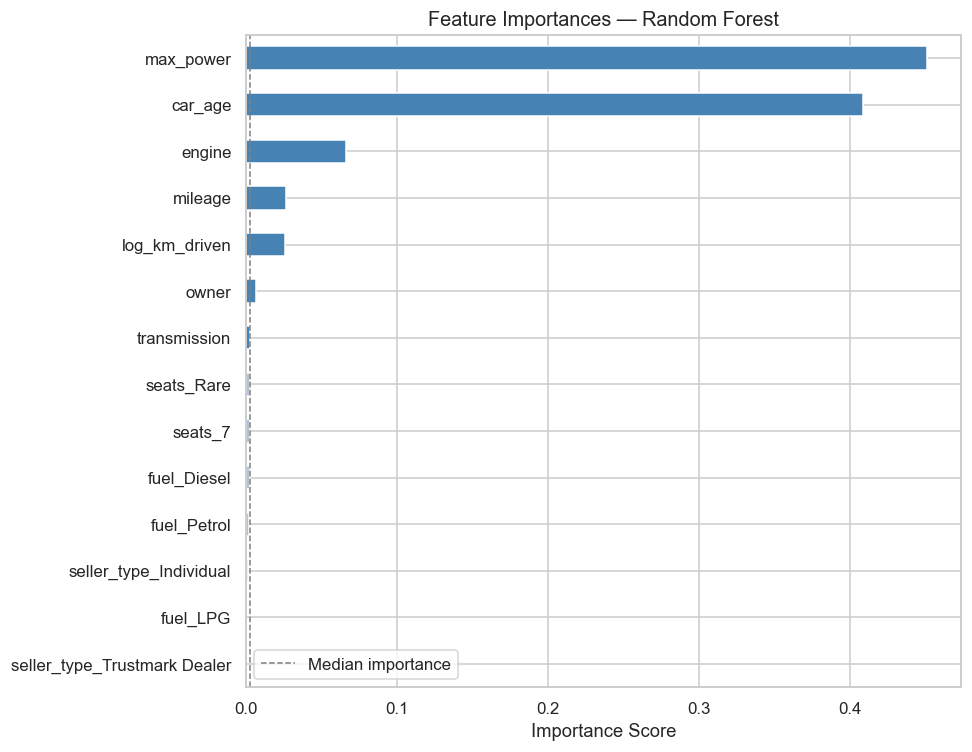

Top 5 features:
max_power        0.4514
car_age          0.4086
engine           0.0664
mileage          0.0266
log_km_driven    0.0258


In [55]:
importances = (pd.Series(final_model.feature_importances_, index=X_train.columns)
               .sort_values(ascending=True))

plt.figure(figsize=(9, 7))
colors = ['steelblue' if v > importances.median() else 'lightsteelblue'
          for v in importances.values]
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importances — Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.axvline(importances.median(), color='gray', linestyle='--',
            linewidth=1, label='Median importance')
plt.legend()
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(importances.sort_values(ascending=False).head().round(4).to_string())